# **Project Report - 7**

# **Bachelor of Computer Applications (BCA)**

# **Semester – V**

#### **Sub**: Deep Learning

#### **Topic:** Loss Function Implementation

#### **Implementation, Calculation, Comparison and Analysis of Mean Squared Error (MSE) and Cross-Entropy Loss**

#### **Submitted By**

#### **Name:** Pragathi BR

#### **Reg no:** 2411021240037

#### **Date of Submission:** 01/10/2026

#### **Faculty Name:** Nagasri. P

# **1. Introduction**

Neural networks are machine learning models that learn patterns from data and make predictions. During prediction, the output generated by a neural network may differ from the actual output.

A **loss function** is used to measure the difference between the actual value and the predicted value.

The loss value represents the prediction error of the model. During neural network training, the model tries to reduce this error and improve its predictions.

Different types of problems require different loss functions.

In this assignment, two basic loss functions are studied:

1. **Mean Squared Error (MSE)**
2. **Cross-Entropy Loss**

Mean Squared Error measures the squared difference between actual and predicted values, while Cross-Entropy measures the difference between actual class labels and predicted probabilities.

# **2. Aim**

To understand how neural networks measure prediction errors by implementing basic loss functions and comparing the difference between actual and predicted values.

The assignment focuses on calculating:

- Mean Squared Error (MSE)
- Cross-Entropy Loss

and understanding when each loss function can be used.

# **3. Assignment Objectives**

The main objectives of this assignment are:

- To understand the concept of loss functions in neural networks.
- To use actual class labels and predicted outputs from a simple classification problem.
- To implement Mean Squared Error using Python.
- To implement Cross-Entropy Loss using Python.
- To compare the calculated loss values.
- To understand the difference between MSE and Cross-Entropy Loss.
- To identify when each loss function can be used.
- To understand the role of loss functions in measuring model prediction errors.

# **4. Task 1: Actual Class Labels and Predicted Outputs**

For this assignment, a simple binary classification problem is considered.

There are two possible classes:

- **Class 0**
- **Class 1**

The actual labels represent the correct class for each sample.

The predicted outputs represent the probability predicted by the model for Class 1.

For example:

- A prediction of `0.9` means the model predicts a 90% probability of Class 1.
- A prediction of `0.2` means the model predicts a 20% probability of Class 1.

The following actual labels and predicted outputs are used:

**Actual Labels:**

`[1, 0, 1, 0]`

**Predicted Outputs:**

`[0.9, 0.2, 0.7, 0.1]`

In [1]:
import numpy as np

# Actual class labels
actual_labels = np.array([1, 0, 1, 0])

# Predicted probabilities
predicted_outputs = np.array([0.9, 0.2, 0.7, 0.1])

print("Actual Labels:", actual_labels)
print("Predicted Outputs:", predicted_outputs)

Actual Labels: [1 0 1 0]
Predicted Outputs: [0.9 0.2 0.7 0.1]


# **5. Understanding the Actual and Predicted Values**

The values can be represented using the following table:

| Sample | Actual Label | Predicted Probability |
|---|---:|---:|
| 1 | 1 | 0.9 |
| 2 | 0 | 0.2 |
| 3 | 1 | 0.7 |
| 4 | 0 | 0.1 |

For binary classification, a probability above 0.5 can generally be classified as Class 1, while a probability below 0.5 can be classified as Class 0.

Therefore:

- `0.9` → Class 1
- `0.2` → Class 0
- `0.7` → Class 1
- `0.1` → Class 0

These predicted probabilities will be used to calculate both MSE and Cross-Entropy Loss.

# **6. Task 2: Mean Squared Error (MSE)**

## **6.1 Definition**

Mean Squared Error is a loss function that calculates the average of the squared differences between actual and predicted values.

It is represented by the formula:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y_i})^2
$$

Where:

- $n$ = Number of samples
- $y_i$ = Actual value
- $\hat{y_i}$ = Predicted value

The difference between the actual and predicted value is squared so that positive and negative errors do not cancel each other.

In [2]:
# Calculate Mean Squared Error

mse = np.mean((actual_labels - predicted_outputs) ** 2)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.037500000000000006


# **6.2 Manual Calculation of MSE**

Actual values:

$$
[1,0,1,0]
$$

Predicted values:

$$
[0.9,0.2,0.7,0.1]
$$

For Sample 1:

$$
(1-0.9)^2 = 0.01
$$

For Sample 2:

$$
(0-0.2)^2 = 0.04
$$

For Sample 3:

$$
(1-0.7)^2 = 0.09
$$

For Sample 4:

$$
(0-0.1)^2 = 0.01
$$

Therefore:

$$
MSE = \frac{0.01+0.04+0.09+0.01}{4}
$$

$$
MSE = \frac{0.15}{4}
$$

$$
\boxed{MSE = 0.0375}
$$

Therefore, the Mean Squared Error for the given predictions is **0.0375**.

# **7. Cross-Entropy Loss**

## **7.1 Definition**

Cross-Entropy Loss is commonly used for classification problems.

It measures the difference between the actual class labels and the predicted probabilities.

For binary classification, the Binary Cross-Entropy formula is:

$$
BCE = -\frac{1}{n}\sum_{i=1}^{n}
[y_i\log(\hat{y_i})+(1-y_i)\log(1-\hat{y_i})]
$$

Where:

- $y_i$ = Actual class label
- $\hat{y_i}$ = Predicted probability
- $n$ = Number of samples

Cross-Entropy gives a larger penalty when the model makes a confident incorrect prediction.

# **7.2 Preventing Numerical Errors**

The logarithm of zero is undefined.

For example:

$$
\log(0)
$$

can cause a numerical error during the calculation.

Therefore, the predicted probabilities are clipped to a very small range using `np.clip()`.

This ensures that the values remain slightly above 0 and slightly below 1.

In [3]:
# Calculate Binary Cross-Entropy Loss

epsilon = 1e-15

# Prevent log(0)
predicted_outputs_clipped = np.clip(
    predicted_outputs,
    epsilon,
    1 - epsilon
)

cross_entropy = -np.mean(
    actual_labels * np.log(predicted_outputs_clipped)
    +
    (1 - actual_labels) * np.log(1 - predicted_outputs_clipped)
)

print("Cross-Entropy Loss:", cross_entropy)

Cross-Entropy Loss: 0.1976348816421487


# **7.3 Cross-Entropy Calculation**

For the first sample:

Actual label = `1`

Predicted probability = `0.9`

$$
-[1\log(0.9)+0\log(1-0.9)]
$$

Approximately:

$$
0.1054
$$

For the second sample:

Actual label = `0`

Predicted probability = `0.2`

$$
-[0\log(0.2)+1\log(1-0.2)]
$$

Approximately:

$$
0.2231
$$

For the third sample:

Actual label = `1`

Predicted probability = `0.7`

Approximately:

$$
0.3567
$$

For the fourth sample:

Actual label = `0`

Predicted probability = `0.1`

Approximately:

$$
0.1054
$$

Taking the average of these values gives:

$$
\boxed{Cross\text{-}Entropy\ Loss \approx 0.1976}
$$

# **8. Visualization of Actual and Predicted Values**

To better understand the difference between the actual class labels and predicted outputs, a bar graph is plotted below.

The graph compares the actual values with the predicted probabilities for each sample.

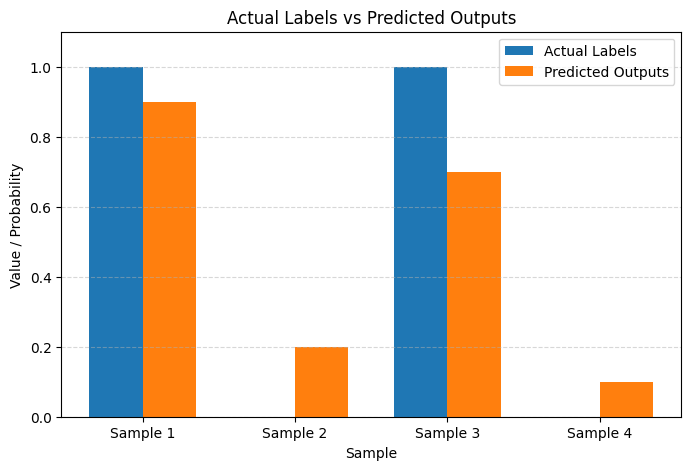

In [7]:
import matplotlib.pyplot as plt

samples = np.arange(1, 5)
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    samples - width/2,
    actual_labels,
    width,
    label="Actual Labels"
)

plt.bar(
    samples + width/2,
    predicted_outputs,
    width,
    label="Predicted Outputs"
)

plt.xlabel("Sample")
plt.ylabel("Value / Probability")
plt.title("Actual Labels vs Predicted Outputs")

plt.xticks(
    samples,
    ["Sample 1", "Sample 2", "Sample 3", "Sample 4"]
)

plt.ylim(0, 1.1)

plt.legend()

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

## **Graph Interpretation**

The graph compares the actual class labels with the predicted probabilities for each sample.

The predicted outputs are close to the corresponding actual labels. This visualization helps us understand the prediction errors that are used to calculate MSE and Cross-Entropy Loss.

# **9. Task 3: Comparison of Results**

The calculated loss values are:

| Loss Function | Calculated Value |
|---|---:|
| Mean Squared Error | 0.0375 |
| Cross-Entropy Loss | 0.1976 |

The numerical values should not be directly compared as one being better simply because it is smaller. MSE and Cross-Entropy are different mathematical measures and have different scales.

MSE measures the squared difference between actual and predicted values.

Cross-Entropy measures how well the predicted probabilities correspond to the actual class labels.

# **9.1 Visualization of Loss Function Comparison**

The following bar graph compares the calculated values of Mean Squared Error (MSE) and Cross-Entropy Loss for the given predictions.

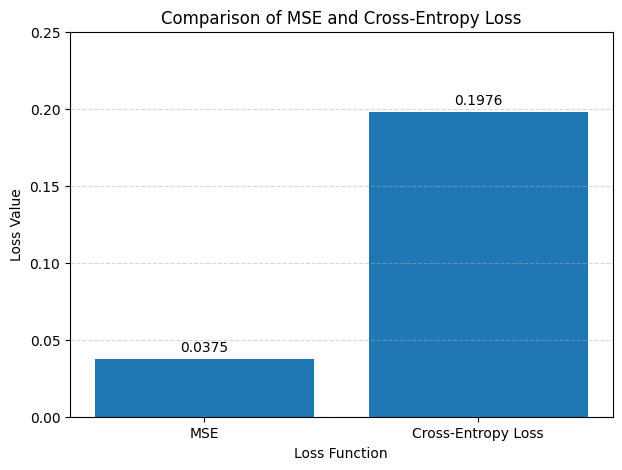

In [6]:
import matplotlib.pyplot as plt

loss_names = ["MSE", "Cross-Entropy Loss"]
loss_values = [mse, cross_entropy]

plt.figure(figsize=(7, 5))

plt.bar(loss_names, loss_values)

plt.xlabel("Loss Function")
plt.ylabel("Loss Value")
plt.title("Comparison of MSE and Cross-Entropy Loss")

plt.ylim(0, 0.25)

for i, value in enumerate(loss_values):
    plt.text(i, value + 0.005, f"{value:.4f}", ha="center")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.show()

# **10. Difference Between MSE and Cross-Entropy Loss**

| Feature | Mean Squared Error (MSE) | Cross-Entropy Loss |
|---|---|---|
| Full Name | Mean Squared Error | Cross-Entropy Loss |
| Common Use | Regression | Classification |
| Measures | Squared prediction error | Difference between actual labels and predicted probabilities |
| Input | Actual and predicted numerical values | Actual labels and predicted probabilities |
| Example | House price prediction | Spam detection |
| Main Purpose | Measure numerical prediction error | Measure probability-based classification error |

# **11. When is MSE Used?**

Mean Squared Error is commonly used for **regression problems**, where the output is a continuous numerical value.

### Examples:

- House price prediction
- Temperature prediction
- Sales forecasting
- Student score prediction
- Demand forecasting

For example, if the actual house price is ₹50 lakh and the model predicts ₹48 lakh, MSE can be used to measure the prediction error.

# **12. When is Cross-Entropy Used?**

Cross-Entropy Loss is commonly used for **classification problems**.

### Examples:

- Spam email detection
- Image classification
- Sentiment analysis
- Disease classification
- Object classification

For example, in spam detection:

- `0` → Not Spam
- `1` → Spam

The model can produce a probability such as `0.90`, meaning that it predicts a 90% probability of the email belonging to the Spam class.

# **13. Why Cross-Entropy is Suitable for Classification**

Cross-Entropy works directly with predicted probabilities.

Suppose the actual class is `1`.

### Prediction 1

$$
Prediction = 0.9
$$

This is a confident and correct prediction.

### Prediction 2

$$
Prediction = 0.1
$$

This is a confident but incorrect prediction.

Cross-Entropy gives a much larger penalty to confident incorrect predictions.

Therefore, Cross-Entropy is widely used when training classification neural networks.

In [4]:
# Verify the results using Scikit-learn

from sklearn.metrics import mean_squared_error, log_loss

mse_check = mean_squared_error(
    actual_labels,
    predicted_outputs
)

cross_entropy_check = log_loss(
    actual_labels,
    predicted_outputs
)

print("MSE using Scikit-learn:", mse_check)
print("Cross-Entropy using Scikit-learn:", cross_entropy_check)

MSE using Scikit-learn: 0.037500000000000006
Cross-Entropy using Scikit-learn: 0.1976348816421487


# **14. Expected Output / Result**

The Mean Squared Error and Cross-Entropy Loss were successfully calculated using Python.

For the given actual labels:

$$
[1,0,1,0]
$$

and predicted outputs:

$$
[0.9,0.2,0.7,0.1]
$$

the calculated values were:

- **Mean Squared Error = 0.0375**
- **Cross-Entropy Loss ≈ 0.1976**

The results demonstrate that different loss functions measure prediction errors in different ways.

# **15. Conclusion**

In this assignment, we understood how neural networks measure prediction errors using loss functions.

We used actual class labels and predicted outputs from a simple binary classification problem.

Mean Squared Error and Cross-Entropy Loss were implemented using Python.

MSE measures the squared difference between actual and predicted values and is commonly used for regression problems.

Cross-Entropy Loss measures the difference between actual class labels and predicted probabilities and is commonly used for classification problems.

Thus, the choice of a loss function depends on the type of machine learning problem and the nature of its output.